# D-Flow: Differentiating through Flows for Controlled Generation

**Image Inverse Problems: Inpainting, Deblurring, Super-Resolution on CIFAR-10**

Inspired by [D-Flow (Ben-Hamu et al., ICML 2024)](https://arxiv.org/abs/2402.14017) and the [minimal implementation](https://github.com/marvinsxtr/d-flow).

D-Flow controls the generation process of a pretrained Flow Matching model by optimizing the source noise $z_0$. For inverse problems $y = \mathcal{A}(x)$:

$$z_0^* = \arg\min_{z_0} \left\| \mathcal{A}\bigl(\mathrm{Flow}(z_0)\bigr) - y \right\|^2$$

The key insight: differentiating through the flow **implicitly projects gradients onto the data manifold**, injecting the learned prior without any explicit regularization.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
torch.manual_seed(42)

Device: cuda


## Velocity Network (UNet)

A time-conditioned UNet that predicts the velocity field $v_\theta(x_t, t)$ for flow matching.

In [2]:
class SinusoidalEmbed(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.mlp = nn.Sequential(nn.Linear(dim, dim * 4), nn.SiLU(), nn.Linear(dim * 4, dim))

    def forward(self, t):
        half = self.dim // 2
        f = torch.exp(-np.log(10000) * torch.arange(half, device=t.device).float() / half)
        emb = t.float().view(-1, 1) * f.view(1, -1)
        emb = torch.cat([emb.sin(), emb.cos()], dim=-1)
        return self.mlp(emb)


class ResBlock(nn.Module):
    def __init__(self, in_c, out_c, tdim):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_c)
        self.conv1 = nn.Conv2d(in_c, out_c, 3, 1, 1)
        self.norm2 = nn.GroupNorm(8, out_c)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, 1, 1)
        self.tproj = nn.Sequential(nn.SiLU(), nn.Linear(tdim, out_c))
        self.skip = nn.Conv2d(in_c, out_c, 1) if in_c != out_c else nn.Identity()

    def forward(self, x, t):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.tproj(t)[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)


class UNet(nn.Module):
    def __init__(self, ch=3, base=64, tdim=128):
        super().__init__()
        self.temb = SinusoidalEmbed(tdim)
        self.cin = nn.Conv2d(ch, base, 3, 1, 1)
        self.d1 = ResBlock(base, base, tdim)
        self.d2 = ResBlock(base, base * 2, tdim)
        self.bot = ResBlock(base * 2, base * 2, tdim)
        self.u2 = ResBlock(base * 4, base, tdim)
        self.u1 = ResBlock(base * 2, base, tdim)
        self.head = nn.Sequential(nn.GroupNorm(8, base), nn.SiLU(), nn.Conv2d(base, ch, 1))
        self.down = nn.AvgPool2d(2)
        self.up = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x, t):
        if t.dim() == 0:
            t = t.unsqueeze(0).expand(x.shape[0])
        te = self.temb(t)
        h0 = self.cin(x)
        h1 = self.d1(h0, te)
        h2 = self.d2(self.down(h1), te)
        h = self.bot(self.down(h2), te)
        h = self.u2(torch.cat([self.up(h), h2], 1), te)
        h = self.u1(torch.cat([self.up(h), h1], 1), te)
        return self.head(h)

print(f'Model parameters: {sum(p.numel() for p in UNet(ch=3).parameters()):,}')

Model parameters: 1,112,451


## Flow Matching Training

Train with the Conditional Optimal Transport path: $x_t = (1-t)\,x_0 + t\,x_1$, where $x_0 \sim \mathcal{N}(0,I)$ and $x_1 \sim p_{\text{data}}$.

The velocity target is $v = x_1 - x_0$ and the loss is $\|v_\theta(x_t, t) - v\|^2$.

In [3]:
transform = transforms.Compose([transforms.ToTensor()])
train_data = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True, num_workers=0, drop_last=True)

def train_flow_matching(epochs=30):
    model = UNet(ch=3, base=64).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs * len(train_loader))

    for epoch in range(epochs):
        total_loss = 0
        t0 = time.time()
        for x1, _ in train_loader:
            x1 = x1.to(device)
            x0 = torch.randn_like(x1)
            t = torch.rand(x1.shape[0], device=device)
            t_exp = t[:, None, None, None]
            xt = (1 - t_exp) * x0 + t_exp * x1
            v_target = x1 - x0

            loss = F.mse_loss(model(xt, t), v_target)
            opt.zero_grad()
            loss.backward()
            opt.step()
            scheduler.step()
            total_loss += loss.item()

        avg = total_loss / len(train_loader)
        elapsed = time.time() - t0
        print(f'Epoch {epoch+1:2d}/{epochs} | Loss: {avg:.4f} | {elapsed:.1f}s')

    return model

Files already downloaded and verified


In [4]:
model = train_flow_matching(epochs=50)

Epoch  1/50 | Loss: 0.1769 | 34.7s
Epoch  2/50 | Loss: 0.1195 | 34.4s
Epoch  3/50 | Loss: 0.1115 | 34.3s
Epoch  4/50 | Loss: 0.1079 | 34.2s
Epoch  5/50 | Loss: 0.1065 | 34.2s
Epoch  6/50 | Loss: 0.1038 | 34.3s
Epoch  7/50 | Loss: 0.1024 | 34.1s
Epoch  8/50 | Loss: 0.1023 | 34.2s
Epoch  9/50 | Loss: 0.1005 | 34.2s
Epoch 10/50 | Loss: 0.1000 | 34.1s
Epoch 11/50 | Loss: 0.0994 | 34.1s
Epoch 12/50 | Loss: 0.0989 | 34.0s
Epoch 13/50 | Loss: 0.0982 | 34.2s
Epoch 14/50 | Loss: 0.0973 | 34.0s
Epoch 15/50 | Loss: 0.0969 | 34.1s
Epoch 16/50 | Loss: 0.0977 | 33.9s
Epoch 17/50 | Loss: 0.0973 | 33.9s
Epoch 18/50 | Loss: 0.0972 | 34.0s
Epoch 19/50 | Loss: 0.0968 | 34.0s
Epoch 20/50 | Loss: 0.0962 | 34.0s
Epoch 21/50 | Loss: 0.0951 | 33.9s
Epoch 22/50 | Loss: 0.0952 | 34.0s
Epoch 23/50 | Loss: 0.0956 | 33.9s
Epoch 24/50 | Loss: 0.0958 | 34.0s
Epoch 25/50 | Loss: 0.0958 | 33.9s
Epoch 26/50 | Loss: 0.0956 | 33.8s
Epoch 27/50 | Loss: 0.0953 | 34.0s
Epoch 28/50 | Loss: 0.0952 | 33.9s
Epoch 29/50 | Loss: 

## Verify: Unconditional Generation

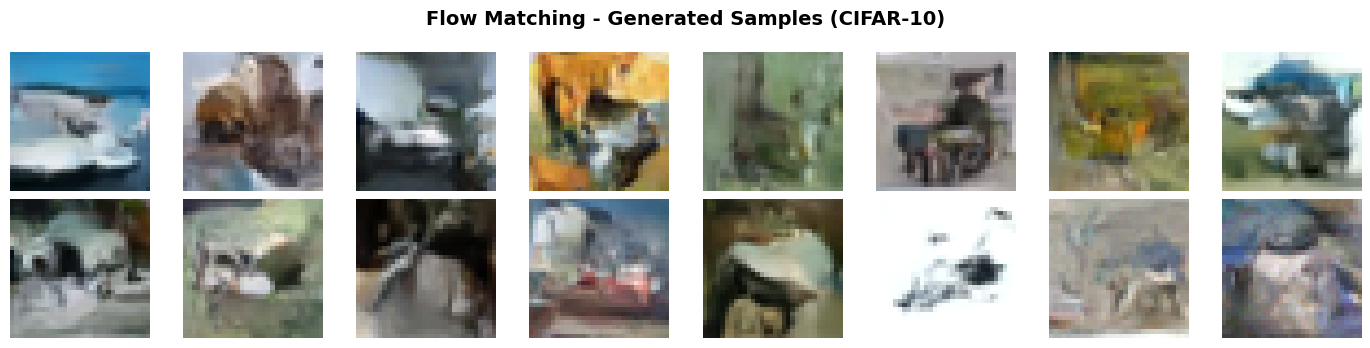

In [5]:
def show_rgb(t):
    return t.permute(1, 2, 0).clamp(0, 1).cpu().numpy()

@torch.no_grad()
def generate_samples(model, n=16, steps=50):
    z = torch.randn(n, 3, 32, 32, device=device)
    dt = 1.0 / steps
    x = z
    for i in range(steps):
        t = torch.full((n,), i * dt, device=device)
        x = x + model(x, t) * dt
    return x.clamp(0, 1)

samples = generate_samples(model, n=16)
fig, axes = plt.subplots(2, 8, figsize=(14, 3.5))
for i, ax in enumerate(axes.flat):
    ax.imshow(show_rgb(samples[i]))
    ax.axis('off')
plt.suptitle('Flow Matching - Generated Samples (CIFAR-10)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## D-Flow: Differentiable ODE Solver & Noise Optimization

The core of D-Flow: solve the ODE **with gradients enabled** so we can backpropagate the measurement loss $\|\mathcal{A}(\mathrm{Flow}(z_0)) - y\|^2$ all the way back to $z_0$.

In [6]:
def solve_flow(z, model, steps=25):
    dt = 1.0 / steps
    x = z
    for i in range(steps):
        t = torch.full((x.shape[0],), i * dt, device=x.device)
        k1 = model(x, t)
        t_mid = torch.full((x.shape[0],), (i + 0.5) * dt, device=x.device)
        k2 = model(x + 0.5 * dt * k1, t_mid)
        x = x + dt * k2
    return x


def dflow_solve(model, y, forward_fn, z_shape, steps=100, ode_steps=25, lr=0.02):
    z = torch.randn(z_shape, device=device)
    z.requires_grad_(True)
    optimizer = torch.optim.Adam([z], lr=lr)

    for i in range(steps):
        optimizer.zero_grad()
        x = solve_flow(z, model, ode_steps)
        loss = F.mse_loss(forward_fn(x), y)
        loss.backward()
        optimizer.step()
        if (i + 1) % 25 == 0:
            print(f'    Step {i+1:3d}/{steps} | Loss: {loss.item():.6f}')

    with torch.no_grad():
        x_final = solve_flow(z, model, ode_steps)
    return x_final.clamp(0, 1)

## Forward Measurement Operators

| Task | Operator $\mathcal{A}$ |
|------|----------------------|
| Inpainting | $\mathcal{A}(x) = M \odot x$ (binary mask) |
| Deblurring | $\mathcal{A}(x) = k * x$ (Gaussian convolution) |
| Super-resolution | $\mathcal{A}(x) = \downarrow_s x$ (downsampling) |

In [7]:
def make_center_mask(h, w, box=16, device='cpu'):
    mask = torch.ones(1, 1, h, w, device=device)
    cy, cx = h // 2, w // 2
    mask[:, :, cy - box // 2:cy + box // 2, cx - box // 2:cx + box // 2] = 0
    return mask


def make_random_mask(h, w, keep_ratio=0.3, device='cpu'):
    mask = (torch.rand(1, 1, h, w, device=device) < keep_ratio).float()
    return mask


def make_blur_kernel(size=7, sigma=2.0, device='cpu'):
    ax = torch.arange(size, device=device).float() - size // 2
    xx, yy = torch.meshgrid(ax, ax, indexing='ij')
    k = torch.exp(-(xx ** 2 + yy ** 2) / (2 * sigma ** 2))
    k = k / k.sum()
    return k.view(1, 1, size, size)


def apply_blur(x, kernel):
    ch = x.shape[1]
    k = kernel.expand(ch, 1, -1, -1)
    pad = kernel.shape[-1] // 2
    return F.conv2d(x, k, padding=pad, groups=ch)


def downsample(x, factor=2):
    return F.avg_pool2d(x, factor)

## Select Test Images

Selected 5 test images: ['airplane', 'frog', 'dog', 'bird', 'automobile']


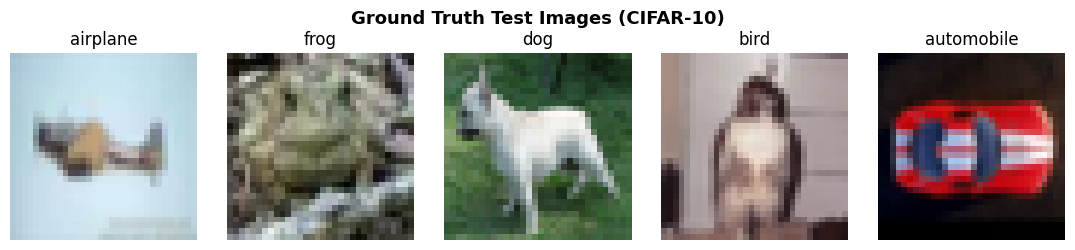

In [8]:
CIFAR_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

test_data = datasets.CIFAR10('./data', train=False, transform=transform)
test_loader = DataLoader(test_data, batch_size=64, shuffle=True)
batch, labels = next(iter(test_loader))

N = 5
unique_labels = []
indices = []
for i, l in enumerate(labels):
    if l.item() not in unique_labels and len(indices) < N:
        unique_labels.append(l.item())
        indices.append(i)
x_gt = batch[indices].to(device)
class_names = [CIFAR_CLASSES[l] for l in unique_labels]
print(f'Selected {N} test images: {class_names}')

fig, axes = plt.subplots(1, N, figsize=(2.2 * N, 2.5))
for i in range(N):
    axes[i].imshow(show_rgb(x_gt[i]))
    axes[i].set_title(class_names[i])
    axes[i].axis('off')
plt.suptitle('Ground Truth Test Images (CIFAR-10)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Inpainting

Recover missing center region. $\mathcal{A}(x) = M \odot x$, with a $16 \times 16$ center mask zeroed out.

  Inpainting image 1/5
    Step  25/200 | Loss: 0.006843
    Step  50/200 | Loss: 0.002660
    Step  75/200 | Loss: 0.001267
    Step 100/200 | Loss: 0.000827
    Step 125/200 | Loss: 0.000660
    Step 150/200 | Loss: 0.000568
    Step 175/200 | Loss: 0.000507
    Step 200/200 | Loss: 0.000461
  Inpainting image 2/5
    Step  25/200 | Loss: 0.022157
    Step  50/200 | Loss: 0.012950
    Step  75/200 | Loss: 0.009788
    Step 100/200 | Loss: 0.007871
    Step 125/200 | Loss: 0.006416
    Step 150/200 | Loss: 0.005278
    Step 175/200 | Loss: 0.004548
    Step 200/200 | Loss: 0.003944
  Inpainting image 3/5
    Step  25/200 | Loss: 0.011449
    Step  50/200 | Loss: 0.008001
    Step  75/200 | Loss: 0.006393
    Step 100/200 | Loss: 0.005006
    Step 125/200 | Loss: 0.004078
    Step 150/200 | Loss: 0.003488
    Step 175/200 | Loss: 0.003052
    Step 200/200 | Loss: 0.002664
  Inpainting image 4/5
    Step  25/200 | Loss: 0.007741
    Step  50/200 | Loss: 0.004232
    Step  75/200 | Loss:

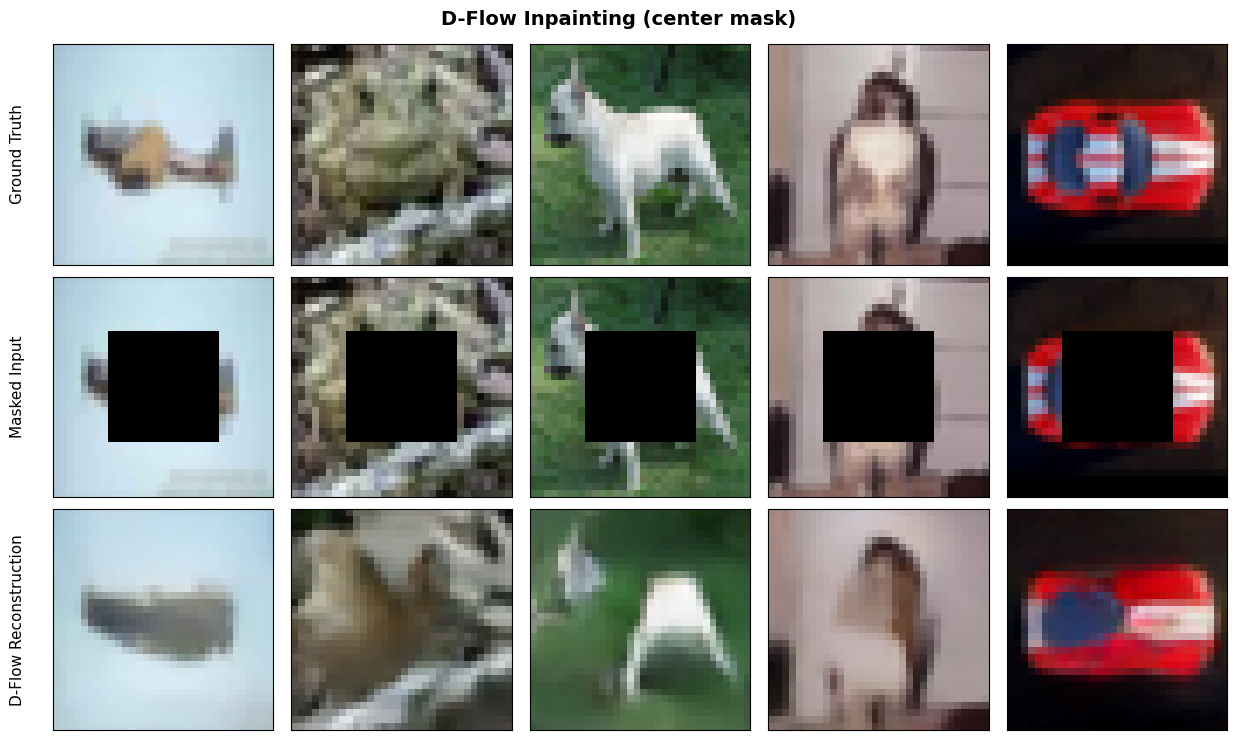

In [9]:
mask = make_center_mask(32, 32, box=16, device=device)
y_inp = x_gt * mask

results_inp = []
for i in range(N):
    print(f'  Inpainting image {i+1}/{N}')
    rec = dflow_solve(model, y_inp[i:i+1], lambda x: x * mask, (1, 3, 32, 32), steps=200, ode_steps=25, lr=0.02)
    results_inp.append(rec)
results_inp = torch.cat(results_inp)

fig, axes = plt.subplots(3, N, figsize=(2.5 * N, 7.5))
titles = ['Ground Truth', 'Masked Input', 'D-Flow Reconstruction']
for i in range(N):
    axes[0, i].imshow(show_rgb(x_gt[i]))
    axes[1, i].imshow(show_rgb(y_inp[i]))
    axes[2, i].imshow(show_rgb(results_inp[i].detach()))
for j, t in enumerate(titles):
    axes[j, 0].set_ylabel(t, fontsize=11, rotation=90, labelpad=20)
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('D-Flow Inpainting (center mask)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Deblurring

Remove Gaussian blur. $\mathcal{A}(x) = k * x$ with a $7 \times 7$ Gaussian kernel ($\sigma = 2$).

  Deblurring image 1/5
    Step  25/200 | Loss: 0.010488
    Step  50/200 | Loss: 0.002377
    Step  75/200 | Loss: 0.001319
    Step 100/200 | Loss: 0.000967
    Step 125/200 | Loss: 0.000789
    Step 150/200 | Loss: 0.000662
    Step 175/200 | Loss: 0.000562
    Step 200/200 | Loss: 0.000485
  Deblurring image 2/5
    Step  25/200 | Loss: 0.004035
    Step  50/200 | Loss: 0.001891
    Step  75/200 | Loss: 0.001011
    Step 100/200 | Loss: 0.000647
    Step 125/200 | Loss: 0.000445
    Step 150/200 | Loss: 0.000336
    Step 175/200 | Loss: 0.000275
    Step 200/200 | Loss: 0.000234
  Deblurring image 3/5
    Step  25/200 | Loss: 0.007320
    Step  50/200 | Loss: 0.002689
    Step  75/200 | Loss: 0.001500
    Step 100/200 | Loss: 0.001006
    Step 125/200 | Loss: 0.000734
    Step 150/200 | Loss: 0.000572
    Step 175/200 | Loss: 0.000468
    Step 200/200 | Loss: 0.000397
  Deblurring image 4/5
    Step  25/200 | Loss: 0.005901
    Step  50/200 | Loss: 0.001802
    Step  75/200 | Loss:

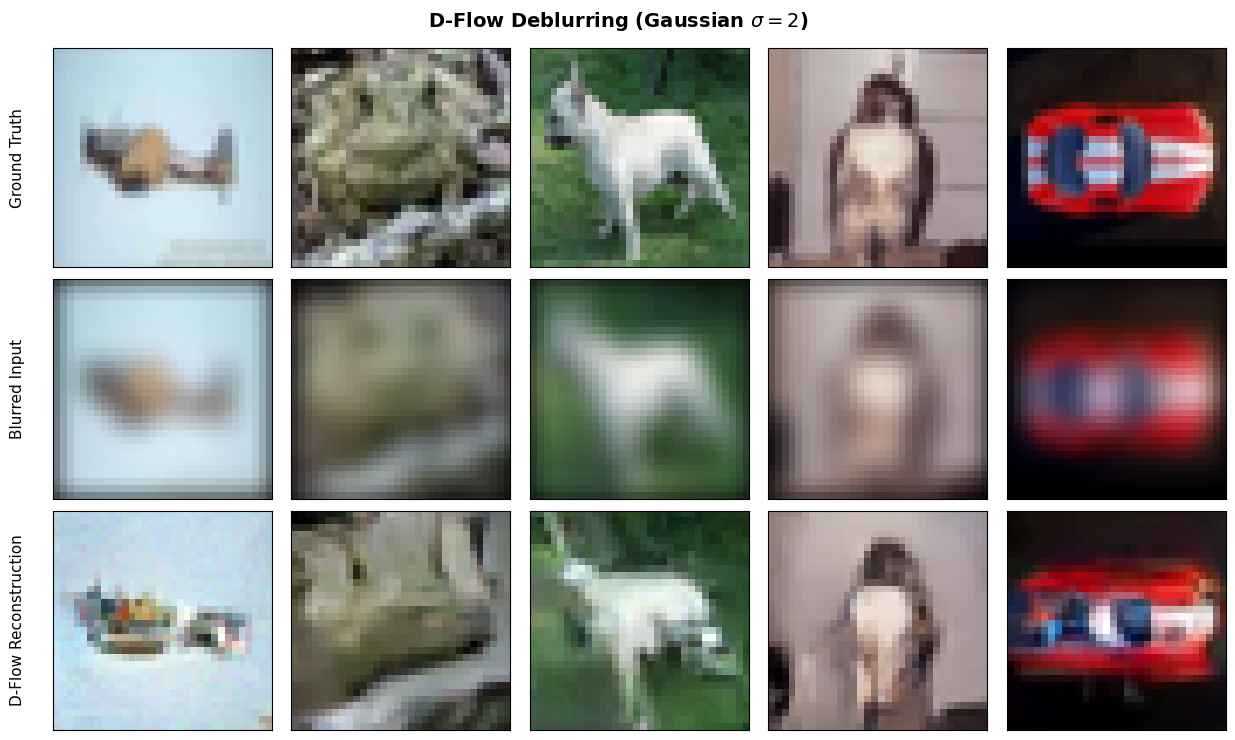

In [10]:
kernel = make_blur_kernel(size=7, sigma=2.0, device=device)
y_blur = apply_blur(x_gt, kernel)

results_blur = []
for i in range(N):
    print(f'  Deblurring image {i+1}/{N}')
    rec = dflow_solve(model, y_blur[i:i+1], lambda x: apply_blur(x, kernel), (1, 3, 32, 32), steps=200, ode_steps=25, lr=0.02)
    results_blur.append(rec)
results_blur = torch.cat(results_blur)

fig, axes = plt.subplots(3, N, figsize=(2.5 * N, 7.5))
titles = ['Ground Truth', 'Blurred Input', 'D-Flow Reconstruction']
for i in range(N):
    axes[0, i].imshow(show_rgb(x_gt[i]))
    axes[1, i].imshow(show_rgb(y_blur[i].detach()))
    axes[2, i].imshow(show_rgb(results_blur[i].detach()))
for j, t in enumerate(titles):
    axes[j, 0].set_ylabel(t, fontsize=11, rotation=90, labelpad=20)
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('D-Flow Deblurring (Gaussian $\sigma=2$)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Super-Resolution ($\times 2$)

Recover high-resolution image from a $2\times$ downsampled measurement. $\mathcal{A}(x) = \downarrow_2 x$.

  Super-resolution image 1/5
    Step  25/200 | Loss: 0.015792
    Step  50/200 | Loss: 0.006400
    Step  75/200 | Loss: 0.003958
    Step 100/200 | Loss: 0.003042
    Step 125/200 | Loss: 0.002276
    Step 150/200 | Loss: 0.001723
    Step 175/200 | Loss: 0.001257
    Step 200/200 | Loss: 0.000916
  Super-resolution image 2/5
    Step  25/200 | Loss: 0.019308
    Step  50/200 | Loss: 0.010858
    Step  75/200 | Loss: 0.007561
    Step 100/200 | Loss: 0.005765
    Step 125/200 | Loss: 0.004409
    Step 150/200 | Loss: 0.003399
    Step 175/200 | Loss: 0.002680
    Step 200/200 | Loss: 0.002141
  Super-resolution image 3/5
    Step  25/200 | Loss: 0.009832
    Step  50/200 | Loss: 0.005623
    Step  75/200 | Loss: 0.003685
    Step 100/200 | Loss: 0.002583
    Step 125/200 | Loss: 0.002119
    Step 150/200 | Loss: 0.001785
    Step 175/200 | Loss: 0.001489
    Step 200/200 | Loss: 0.001203
  Super-resolution image 4/5
    Step  25/200 | Loss: 0.018277
    Step  50/200 | Loss: 0.008164


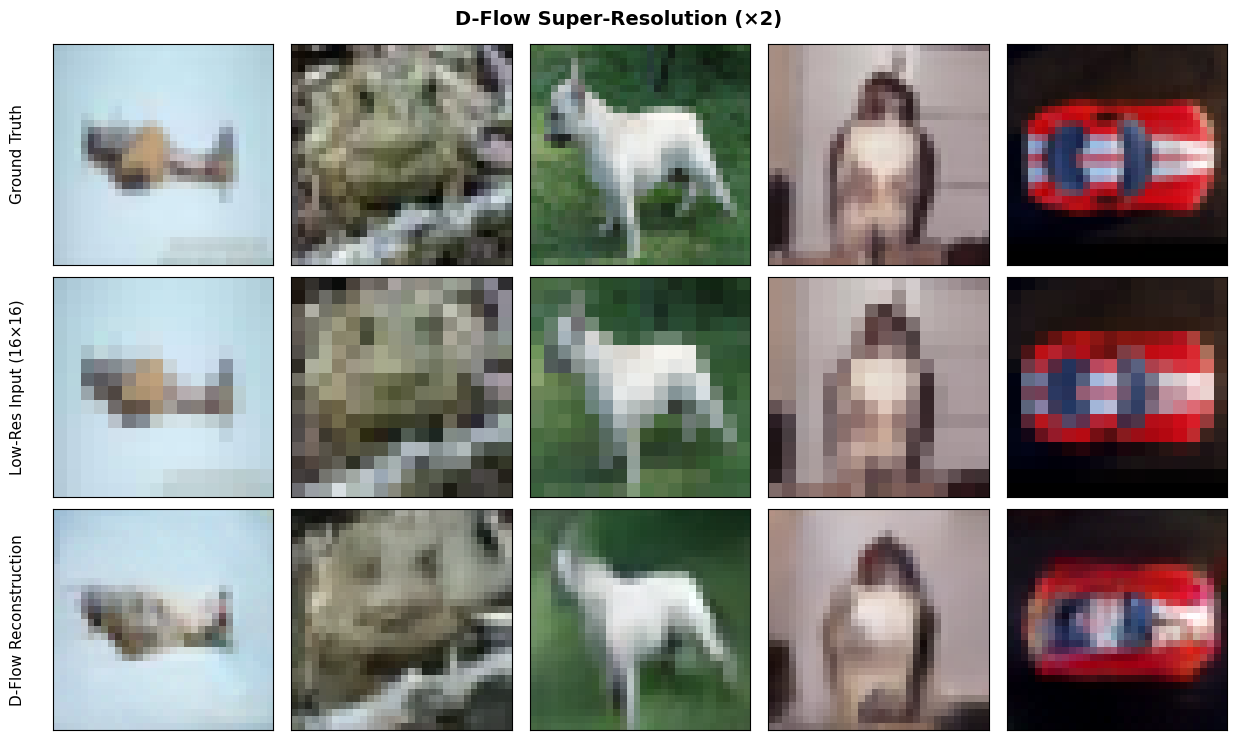

In [11]:
SR_FACTOR = 2
y_lr = downsample(x_gt, SR_FACTOR)

results_sr = []
for i in range(N):
    print(f'  Super-resolution image {i+1}/{N}')
    rec = dflow_solve(model, y_lr[i:i+1], lambda x: downsample(x, SR_FACTOR), (1, 3, 32, 32), steps=200, ode_steps=25, lr=0.02)
    results_sr.append(rec)
results_sr = torch.cat(results_sr)

y_lr_up = F.interpolate(y_lr, scale_factor=SR_FACTOR, mode='nearest')

fig, axes = plt.subplots(3, N, figsize=(2.5 * N, 7.5))
titles = ['Ground Truth', f'Low-Res Input ({32//SR_FACTOR}×{32//SR_FACTOR})', 'D-Flow Reconstruction']
for i in range(N):
    axes[0, i].imshow(show_rgb(x_gt[i]))
    axes[1, i].imshow(show_rgb(y_lr_up[i].detach()))
    axes[2, i].imshow(show_rgb(results_sr[i].detach()))
for j, t in enumerate(titles):
    axes[j, 0].set_ylabel(t, fontsize=11, rotation=90, labelpad=20)
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle(f'D-Flow Super-Resolution (×{SR_FACTOR})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Combined Comparison

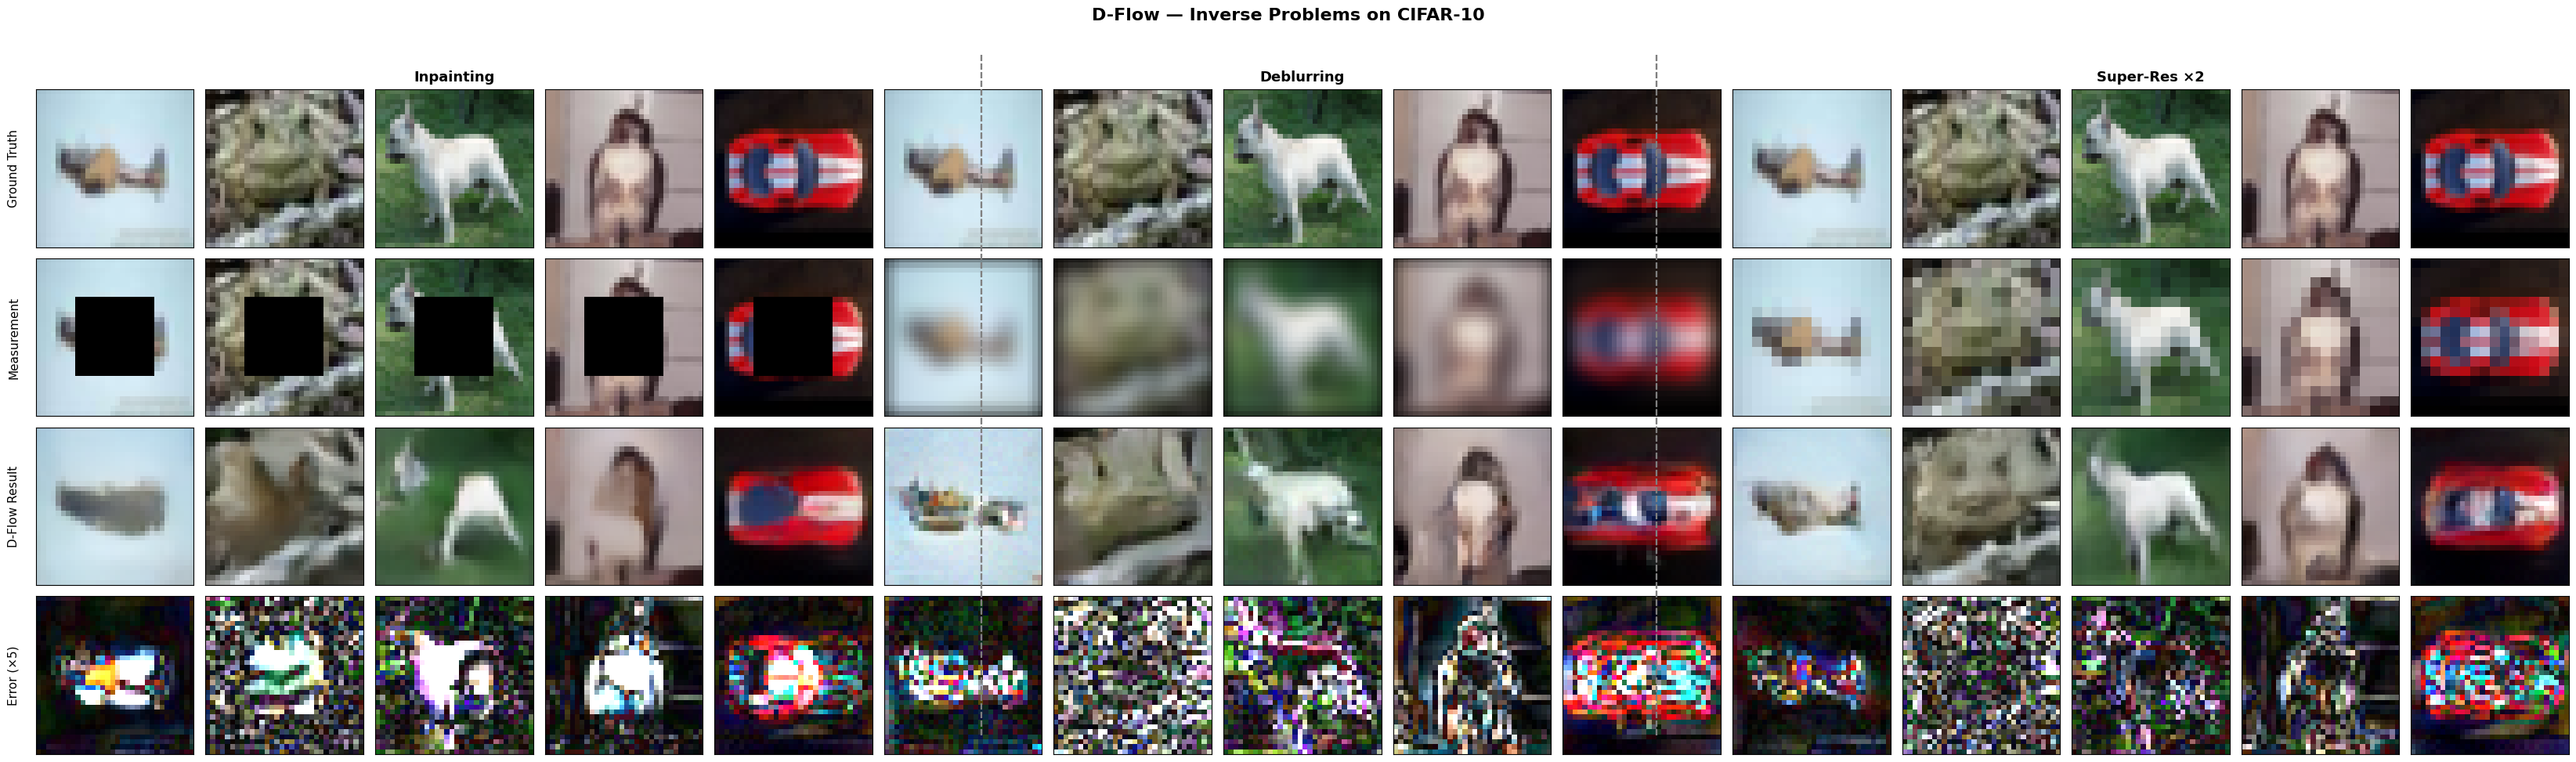

In [12]:
fig, axes = plt.subplots(4, 3 * N, figsize=(3 * N * 2.2, 10))

task_data = [
    ('Inpainting', y_inp, results_inp),
    ('Deblurring', y_blur, results_blur),
    ('Super-Res ×2', y_lr_up, results_sr),
]

row_labels = ['Ground Truth', 'Measurement', 'D-Flow Result', 'Error (×5)']

for task_idx, (task_name, y_vis, recon) in enumerate(task_data):
    col_offset = task_idx * N
    for i in range(N):
        c = col_offset + i
        gt_img = show_rgb(x_gt[i])
        y_img = show_rgb(y_vis[i].detach())
        rec_img = show_rgb(recon[i].detach())
        err_img = (np.abs(gt_img - rec_img) * 5).clip(0, 1)

        axes[0, c].imshow(gt_img)
        axes[1, c].imshow(y_img)
        axes[2, c].imshow(rec_img)
        axes[3, c].imshow(err_img)

    mid_col = col_offset + N // 2
    axes[0, mid_col].set_title(task_name, fontsize=13, fontweight='bold', pad=8)

for j, label in enumerate(row_labels):
    axes[j, 0].set_ylabel(label, fontsize=11, rotation=90, labelpad=15)

for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])

for task_idx in range(1, 3):
    col = task_idx * N
    for row in range(4):
        pos = axes[row, col].get_position()
        fig.add_artist(plt.Line2D(
            [pos.x0 - 0.005, pos.x0 - 0.005], [0.05, 0.92],
            transform=fig.transFigure, color='gray', linewidth=1.5, linestyle='--'
        ))

plt.suptitle('D-Flow — Inverse Problems on CIFAR-10', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Quantitative Evaluation

In [13]:
def psnr(x, y):
    mse = F.mse_loss(x, y).item()
    if mse == 0:
        return float('inf')
    return 10 * np.log10(1.0 / mse)

tasks = {
    'Inpainting': results_inp,
    'Deblurring': results_blur,
    'Super-Res ×2': results_sr,
}

print(f'{"Task":<16} | {"Mean PSNR (dB)":>14}')
print('-' * 35)
for name, recon in tasks.items():
    vals = [psnr(recon[i:i+1], x_gt[i:i+1]) for i in range(N)]
    print(f'{name:<16} | {np.mean(vals):>11.2f} dB')

Task             | Mean PSNR (dB)
-----------------------------------
Inpainting       |       18.32 dB
Deblurring       |       19.79 dB
Super-Res ×2     |       23.45 dB


## Bonus: Random Pixel Inpainting (30% observed)

  Random inpainting image 1/5
    Step  25/200 | Loss: 0.002466
    Step  50/200 | Loss: 0.001303
    Step  75/200 | Loss: 0.000732
    Step 100/200 | Loss: 0.000487
    Step 125/200 | Loss: 0.000330
    Step 150/200 | Loss: 0.000259
    Step 175/200 | Loss: 0.000220
    Step 200/200 | Loss: 0.000193
  Random inpainting image 2/5
    Step  25/200 | Loss: 0.007362
    Step  50/200 | Loss: 0.005743
    Step  75/200 | Loss: 0.003426
    Step 100/200 | Loss: 0.002409
    Step 125/200 | Loss: 0.001630
    Step 150/200 | Loss: 0.001184
    Step 175/200 | Loss: 0.000879
    Step 200/200 | Loss: 0.000654
  Random inpainting image 3/5
    Step  25/200 | Loss: 0.003975
    Step  50/200 | Loss: 0.001908
    Step  75/200 | Loss: 0.001416
    Step 100/200 | Loss: 0.001249
    Step 125/200 | Loss: 0.001147
    Step 150/200 | Loss: 0.001066
    Step 175/200 | Loss: 0.000992
    Step 200/200 | Loss: 0.000921
  Random inpainting image 4/5
    Step  25/200 | Loss: 0.006588
    Step  50/200 | Loss: 0.003

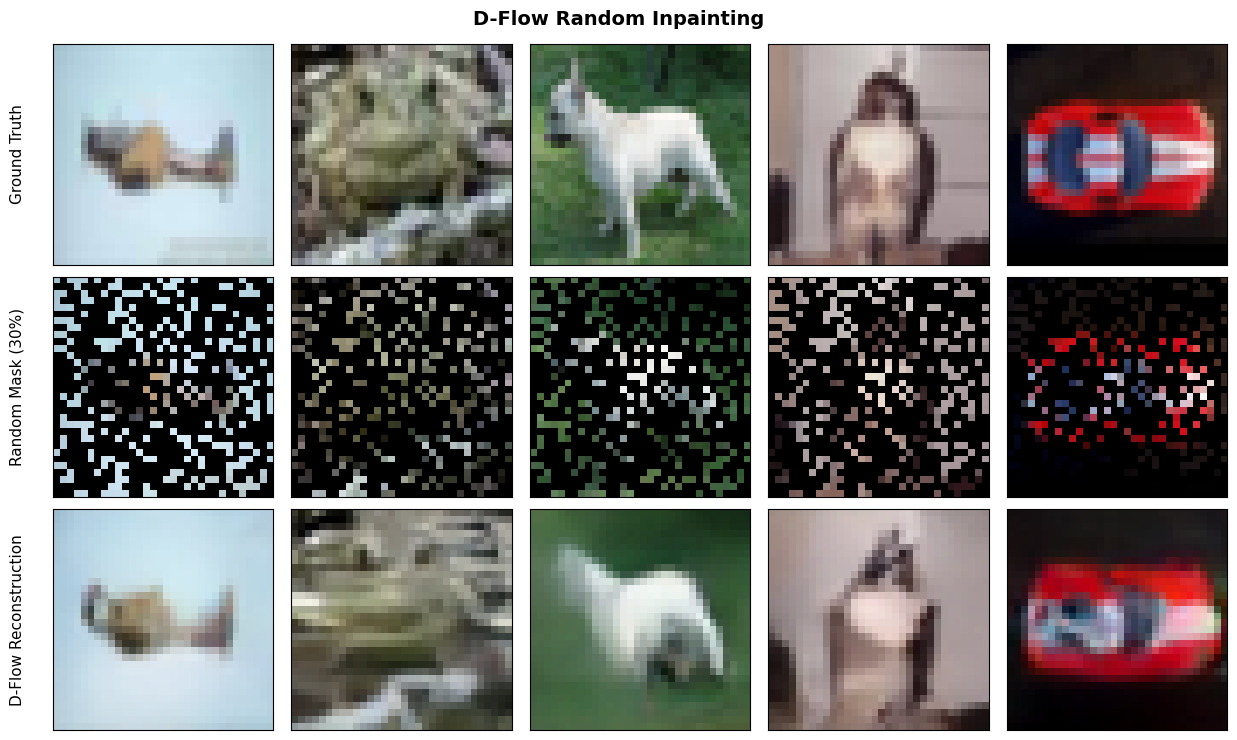

Random Inpainting Mean PSNR: 21.71 dB


In [14]:
torch.manual_seed(123)
rand_mask = make_random_mask(32, 32, keep_ratio=0.3, device=device)
y_rand = x_gt * rand_mask

results_rand = []
for i in range(N):
    print(f'  Random inpainting image {i+1}/{N}')
    rec = dflow_solve(model, y_rand[i:i+1], lambda x: x * rand_mask, (1, 3, 32, 32), steps=200, ode_steps=25, lr=0.02)
    results_rand.append(rec)
results_rand = torch.cat(results_rand)

fig, axes = plt.subplots(3, N, figsize=(2.5 * N, 7.5))
titles = ['Ground Truth', 'Random Mask (30%)', 'D-Flow Reconstruction']
for i in range(N):
    axes[0, i].imshow(show_rgb(x_gt[i]))
    axes[1, i].imshow(show_rgb(y_rand[i].detach()))
    axes[2, i].imshow(show_rgb(results_rand[i].detach()))
for j, t in enumerate(titles):
    axes[j, 0].set_ylabel(t, fontsize=11, rotation=90, labelpad=20)
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('D-Flow Random Inpainting', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

vals = [psnr(results_rand[i:i+1], x_gt[i:i+1]) for i in range(N)]
print(f'Random Inpainting Mean PSNR: {np.mean(vals):.2f} dB')